In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
plt.rcParams['axes.unicode_minus'] = False
cancer = load_breast_cancer()

In [2]:
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [3]:
data = load_breast_cancer()
feature_names = list(data.feature_names) 

In [4]:
X = pd.DataFrame(data.data, columns=feature_names)

In [5]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
y_original = pd.Series(data.target, name='target_original')
y = 1 - y_original
y.name = 'target'

compare_label = pd.DataFrame({
    'target_original (0=악성, 1=양성)': y_original,
    'target (0=양성, 1=악성)': y
})
compare_label.head()

,"target_original (0=악성, 1=양성)","target (0=양성, 1=악성)"
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [7]:
label_to_name = {0:'benign', 1:'malignant'}
target_name = y.map(label_to_name)
target_name.name = 'target_name'
target_name.value_counts()

target_name
benign       357
malignant    212
Name: count, dtype: int64

In [8]:
df = X.copy()
df['target'] = y.values
df['target_name'] = target_name.values
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,malignant


In [9]:
print('feature 컬럼만 선택한 표의 크기:', df[feature_names].shape)
print('feature + target표의 크기:', df[feature_names + ['target']].shape)

feature 컬럼만 선택한 표의 크기: (569, 30)
feature + target표의 크기: (569, 31)


In [10]:
# 결측치 확인
missing_count = df.isnull().sum()

print(missing_count)
print('\n전체 결측치 총합:', missing_count.sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
target_name                0
dtype: int64

전체 결측치 총합: 0


In [11]:
count_by_class = df['target_name'].value_counts()
print('클래스별 개수')
print(count_by_class)

ratio_by_class = df['target_name'].value_counts(normalize=True)
print('클래스별 비율')
print(ratio_by_class)

클래스별 개수
target_name
benign       357
malignant    212
Name: count, dtype: int64
클래스별 비율
target_name
benign       0.627417
malignant    0.372583
Name: proportion, dtype: float64


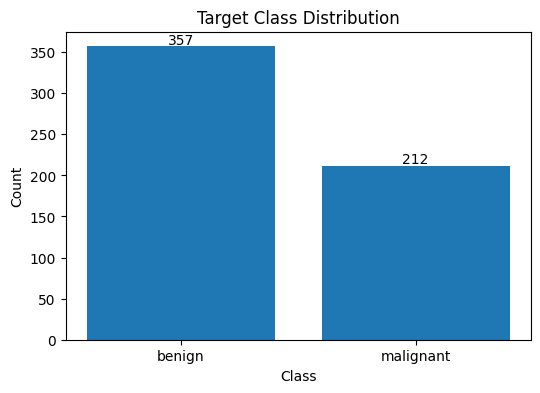

In [12]:
plt.figure(figsize=(6,4))
plt.bar(count_by_class.index, count_by_class.values)
plt.title('Target Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
# 막대그래프 위에 수치 출력
for i, value in enumerate(count_by_class.values):
    plt.text(i, value + 3, str(value), ha='center')

In [13]:
df[feature_names].describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [14]:
mean_compare = df.groupby('target_name')[feature_names].mean().T # transpose
mean_compare

target_name,benign,malignant
mean radius,12.146524,17.462830
mean texture,17.914762,21.604906
mean perimeter,78.075406,115.365377
mean area,462.790196,978.376415
mean smoothness,0.092478,0.102898
mean compactness,0.080085,0.145188
mean concavity,0.046058,0.160775
mean concave points,0.025717,0.087990
mean symmetry,0.174186,0.192909
mean fractal dimension,0.062867,0.062680


In [15]:
# 악성평균에서 양성 평균 뺀 차이. 
mean_compare['difference'] = mean_compare['malignant'] - mean_compare['benign']

In [16]:
mean_compare['abs_difference'] = mean_compare['difference'].abs()

In [17]:
mean_compare.sort_values(by='abs_difference', ascending=False)

target_name,benign,malignant,difference,abs_difference
worst area,558.899440,1422.286321,863.386881,863.386881
mean area,462.790196,978.376415,515.586219,515.586219
worst perimeter,87.005938,141.370330,54.364392,54.364392
area error,21.135148,72.672406,51.537257,51.537257
mean perimeter,78.075406,115.365377,37.289971,37.289971
worst radius,13.379801,21.134811,7.755010,7.755010
worst texture,23.515070,29.318208,5.803138,5.803138
mean radius,12.146524,17.462830,5.316306,5.316306
mean texture,17.914762,21.604906,3.690144,3.690144
perimeter error,2.000321,4.323929,2.323608,2.323608


In [18]:
selected_features = [
  'mean radius',
  'mean perimeter',
  'mean area',
  'mean concave points',
  'worst radius',
  'worst perimeter',
  'worst area',
  'worst concave points'
]
print('선택한 feature 개수:', len(selected_features))

선택한 feature 개수: 8


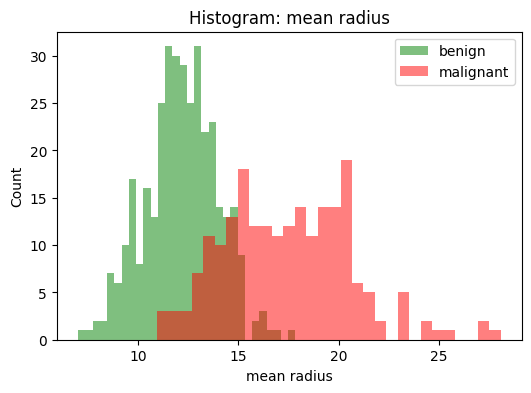

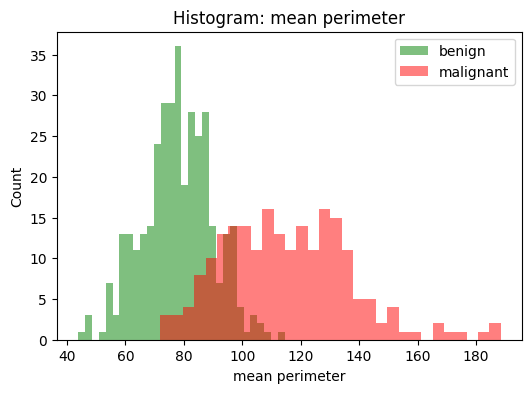

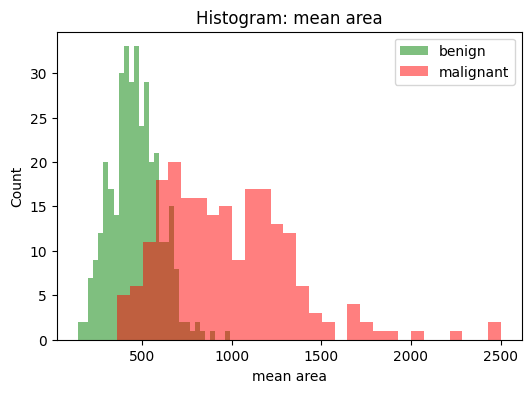

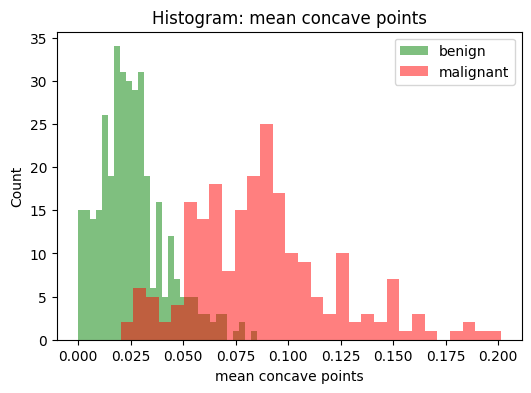

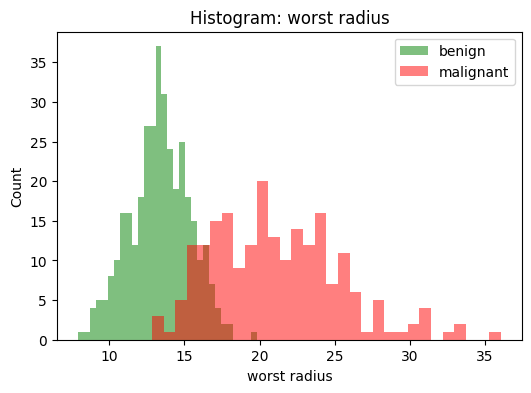

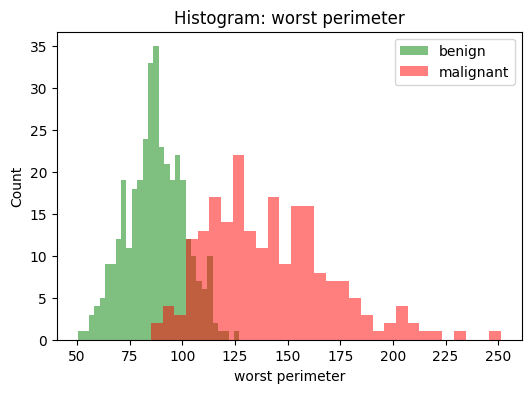

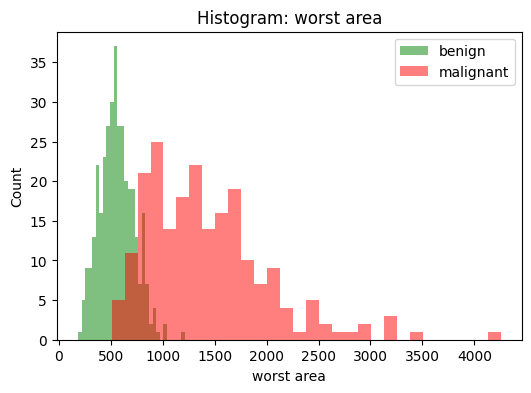

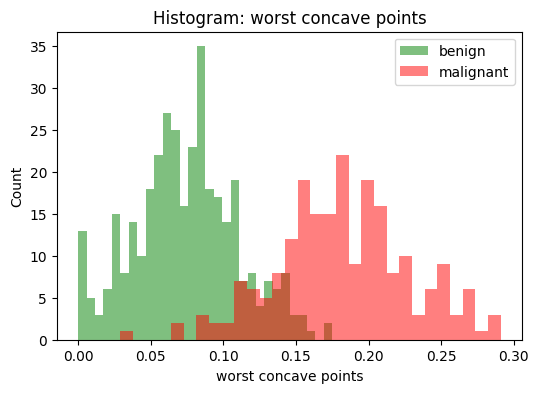

In [19]:
# 조건걸어서 행 분리
benign_df = df[df['target_name'] == 'benign']
malignant_df = df[df['target_name'] == 'malignant']

for feature in selected_features:
    plt.figure(figsize=(6, 4))
    # 막대를 30개 구간으로 나눔. alpha=0.5 : 반투명
    plt.hist(benign_df[feature], bins=30, alpha=0.5, label='benign', color='green')

    plt.hist(malignant_df[feature], bins=30, alpha=0.5, label='malignant', color='red')
    plt.title('Histogram: ' + feature)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend() # benign/malignant 구분 범례 표시


C:\Users\user\AppData\Local\Temp\ipykernel_14000\3938654765.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=['benign', 'malignant'])
C:\Users\user\AppData\Local\Temp\ipykernel_14000\3938654765.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=['benign', 'malignant'])
C:\Users\user\AppData\Local\Temp\ipykernel_14000\3938654765.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=['benign', 'malignant'])
C:\Users\user\AppData\Local\Temp\ipykernel_14000\3938654765.py:6: MatplotlibDeprecationWarning: The 'labels' parame

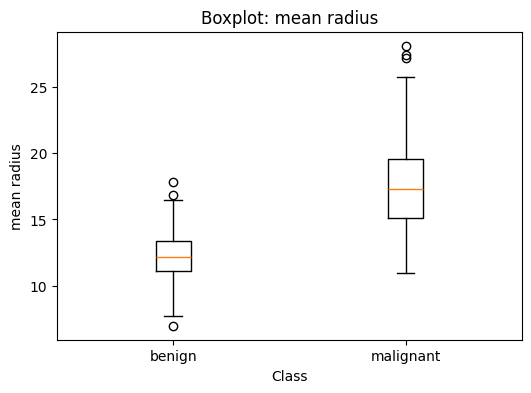

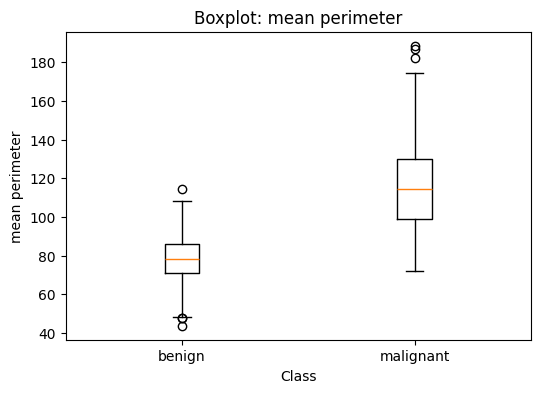

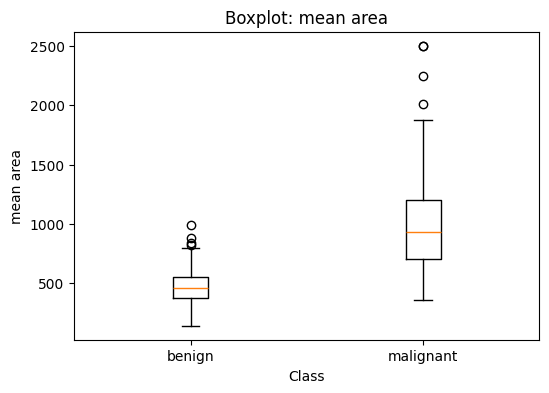

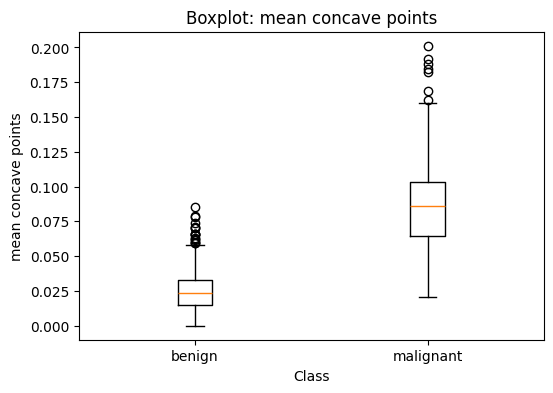

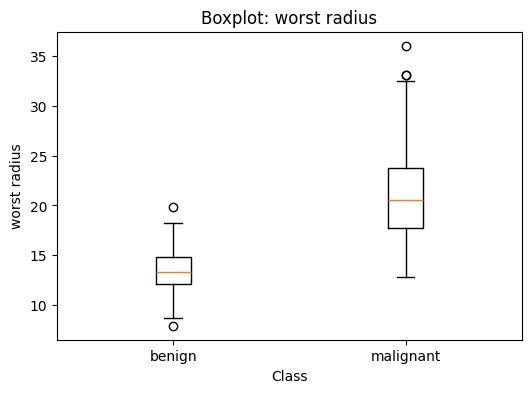

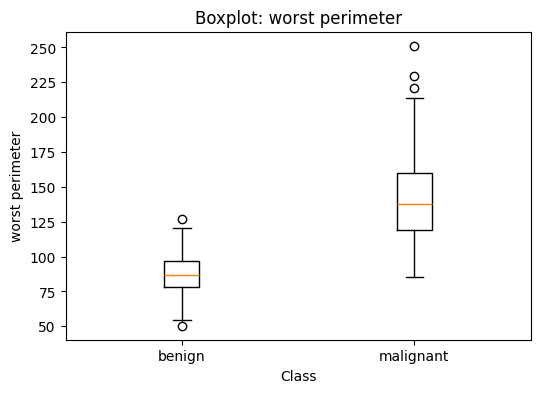

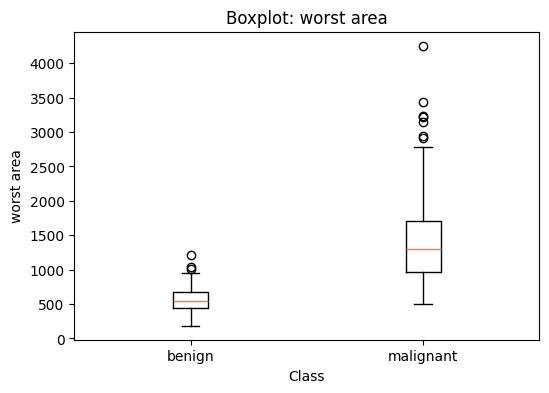

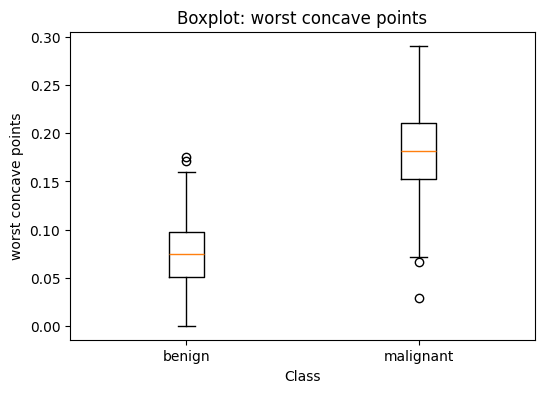

In [20]:
# 박스 플롯 그리기
for feature in selected_features:
    plt.figure(figsize=(6, 4))
    # 박스 2개 (양성, 악성) 한번에 그리기
    data_for_box = [benign_df[feature], malignant_df[feature]]
    plt.boxplot(data_for_box, labels=['benign', 'malignant'])
    plt.title('Boxplot: ' + feature)
    plt.xlabel('Class')
    plt.ylabel(feature)

In [21]:
# target과 feature의 상관관계 계산
target_corr = df[feature_names + ['target']].corr()['target'].drop('target')
target_corr.sort_values(ascending=False).head(15)

worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
mean compactness        0.596534
worst compactness       0.590998
radius error            0.567134
perimeter error         0.556141
area error              0.548236
Name: target, dtype: float64

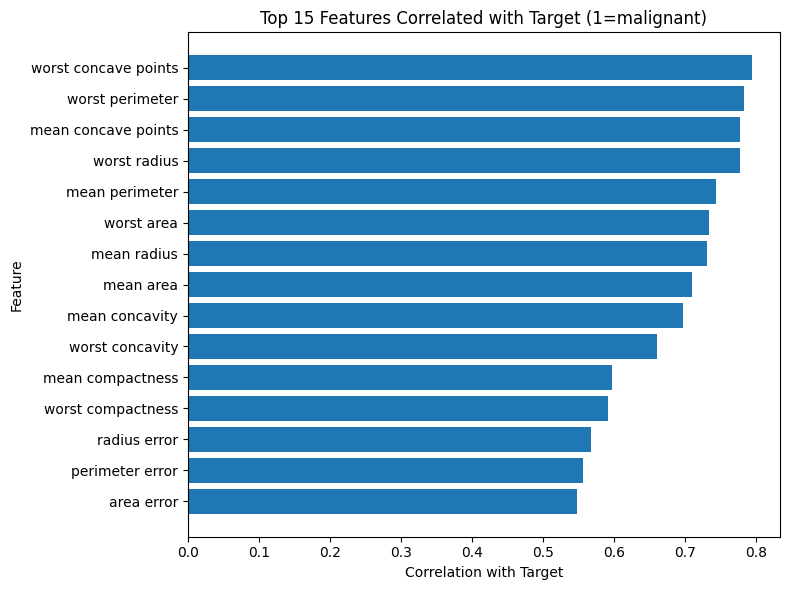

In [22]:
top15_corr = target_corr.sort_values(ascending=False).head(15)
plt.figure(figsize=(8,6))
plt.barh(top15_corr.index, top15_corr.values)
plt.gca().invert_yaxis()
plt.title('Top 15 Features Correlated with Target (1=malignant)')
plt.xlabel('Correlation with Target')
plt.ylabel('Feature')
plt.tight_layout()

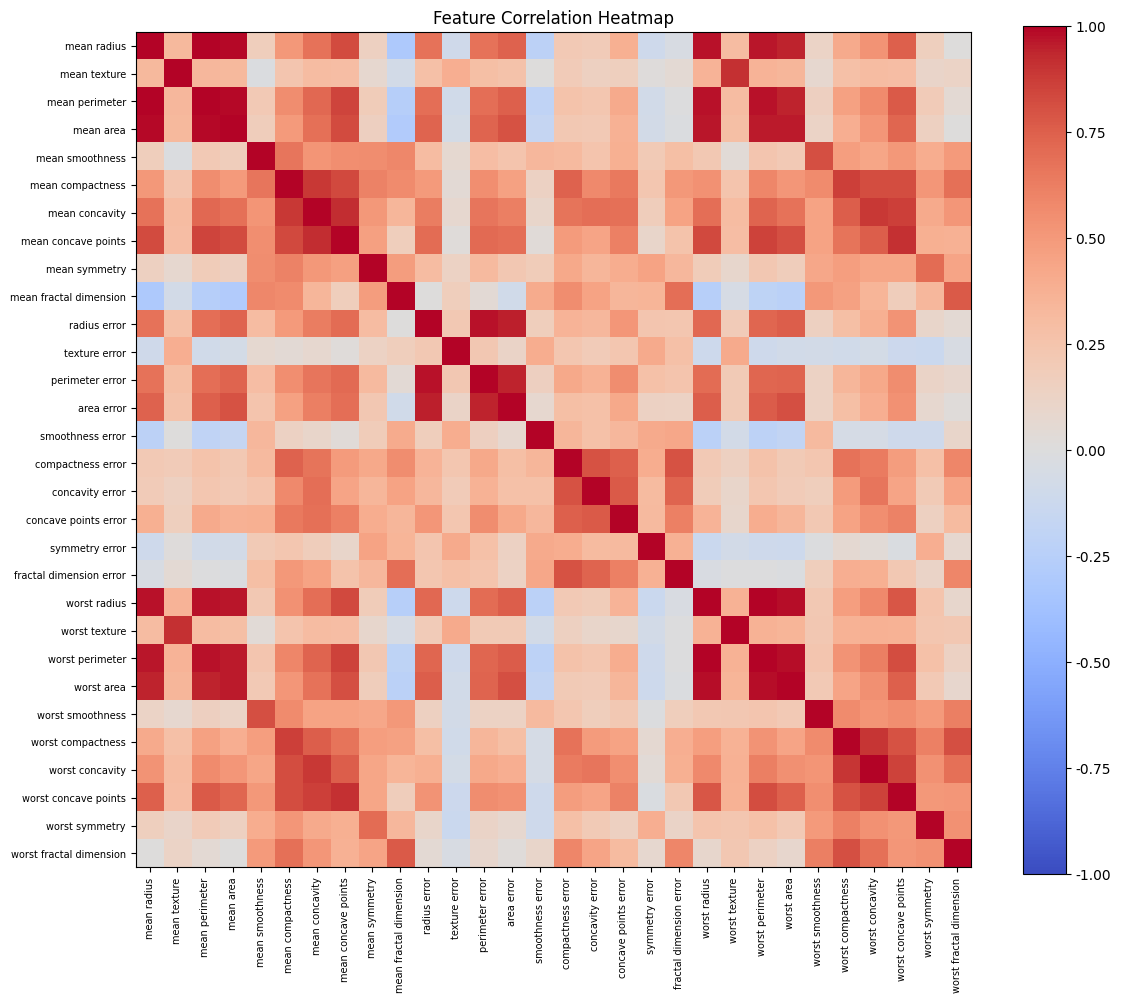

In [23]:
corr_matrix = df[feature_names].corr()
plt.figure(figsize=(12, 10))

image = plt.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(image)
plt.xticks(range(len(feature_names)), feature_names, rotation=90, fontsize=7)
plt.yticks(range(len(feature_names)), feature_names, fontsize=7)

plt.title('Feature Correlation Heatmap')
plt.tight_layout()

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('학습용 입력 크기:', X_train.shape)
print('평가용 입력 크기:', X_test.shape)

print('\n학습용 악성 비율:', round(y_train.mean(), 3))
print('평가용 악성 비율:', round(y_test.mean(), 3))

학습용 입력 크기: (455, 30)
평가용 입력 크기: (114, 30)

학습용 악성 비율: 0.374
평가용 악성 비율: 0.368


In [25]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

print('모델 생성 완료:', type(model).__name__)

모델 생성 완료: XGBClassifier


In [26]:
model.fit(X_train, y_train)

print('모델 학습 완료')

모델 학습 완료


In [27]:
y_pred = model.predict(X_test)

# 악성(1) 확률 구하기
y_pred_proba = model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy(정확도):', round(accuracy, 4))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print('ROC_AUC:', round(roc_auc, 4))

Accuracy(정확도): 0.9649
ROC_AUC: 0.9967


In [28]:
report = classification_report(
    y_test,
    y_pred,
    target_names=['benign', 'malignant']
)

print(report)

              precision    recall  f1-score   support

      benign       0.95      1.00      0.97        72
   malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [29]:
from sklearn.metrics import roc_curve

In [30]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_proba)

Text(0, 0.5, 'True Positive Rate (Recall)')

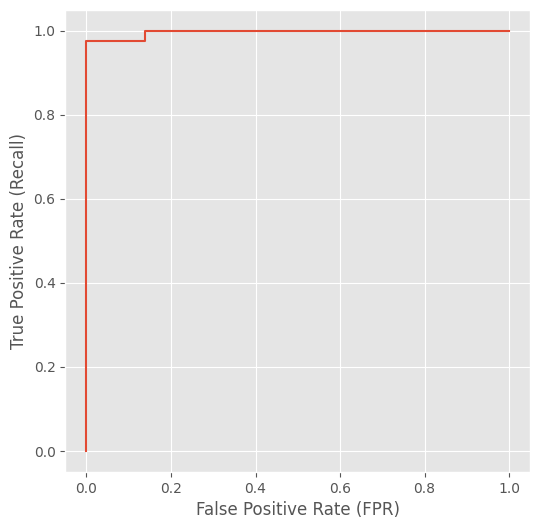

In [31]:
plt.style.use('ggplot')
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (Recall)')

In [32]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[72  0]
 [ 4 38]]


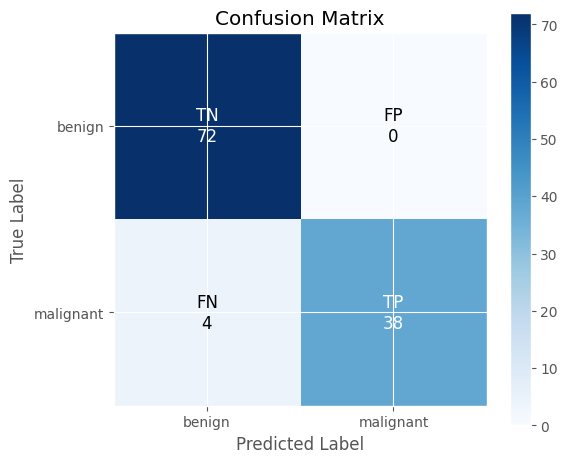

In [33]:
cell_labels = [['TN', 'FP'], ['FN', 'TP']]
plt.figure(figsize=(6, 5))

plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.xticks([0, 1], ['benign', 'malignant'])
plt.yticks([0, 1], ['benign', 'malignant'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

for row in range(2):
    for col in range(2):
        text = cell_labels[row][col] + '\n' + str(cm[row, col])
        color = 'white' if cm[row, col] > cm.max() / 2 else 'black'
        plt.text(col, row, text, ha='center', va='center', color=color, fontsize=12)
plt.tight_layout()

In [34]:
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
})

importance_df = importance_df.sort_values('importance', ascending=False)

importance_df.head(15)

,feature,importance
22,worst perimeter,0.325854
7,mean concave points,0.168878
20,worst radius,0.132685
27,worst concave points,0.107395
26,worst concavity,0.034402
14,smoothness error,0.024641
21,worst texture,0.021746
3,mean area,0.021613
1,mean texture,0.020148
10,radius error,0.015719


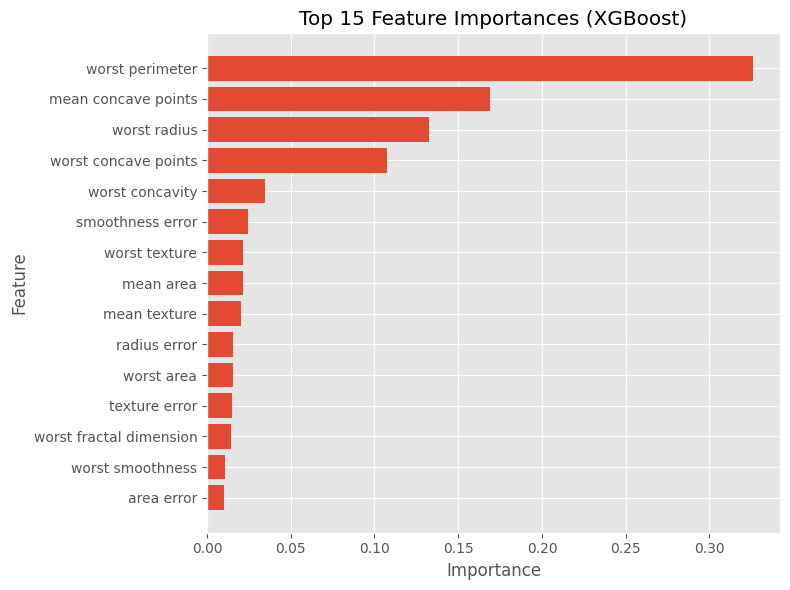

In [35]:
top15_importance = importance_df.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top15_importance['feature'], top15_importance['importance'])

plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()